In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Experiment: MobileNetV2 + Triplet Loss - 204 Authors

Author identification experiment on handwritten documents using **Siamese Networks with Triplet Loss**.

**Objetive**: learn dn embedding space where patches from the same author cluster together and patches from different authors are pushed apart, enabling identification by similarity.

**Experiment setup**:
- Dataset: variant 4 (lines removed, grayscale)
- Authors: 204 (range 204)
- Architecture: MobileNetV2 fine-tuned + embedding head + triplet siamese network.

In [2]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
)
import seaborn as sns

In [3]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 151.1 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=4b4eb1e7fd6d0897d533d533bc3ead8368c91084e1c3d90f2ae5dcaec11f57d9
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors_range=range(0, 204),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=50,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=64,
        validation=32,
        test=16,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
upload_source(
    source=f"{config.project_path}/src",
    source_dest="./src"
)

In [8]:
upload_source(
    source=f"{config.project_path}/data/datasets/180_360_90",
    source_dest=f"./dataset"
)

In [9]:
upload_source(
    source=f"{config.project_path}/data/datasets/experiments",
    source_dest="./models"
)

In [10]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [11]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [12]:
from src.models import (
    MobileNetV2Backbone,
    TripletLoss,
    EmbeddingNetwork,
    SiameseFactory
)
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
    BaseMetricTrainer,
)
from src.evaluator import (
    TripletEvaluator,
    EmbeddingEvaluator,
    EmbeddingVisualizer,
)

In [13]:
from src.evaluator.embedding_utils import EmbeddingExtractor, UMAPReducer
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)

In [14]:
logger = LoggerFactory.get_logger(
    "mobile_test_204_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [15]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [16]:
!tar -xzf {dataset_path} -C ./

## Dataset

The dataset is stored in .zarr format with spatial separation between train and test:

```
dataset.zarr
├── non_test/   ← patches from the main writing area (train + val)
└── test/       ← patches from the test area, physically separated in the original image
```

`SelectiveDataLoader` selects a subset of authors and builds the three splits (train, val, test) guaranteeing that **no patch from the test area appears in train o val**.
This eliminates data leakage by spatial position.

In [17]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [18]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

13:49:46 - mobile_test_204_4 - INFO - Total patches selected: 128891
13:49:46 - mobile_test_204_4 - INFO - Train: 96668 | Val: 32223 | Test: 8946
13:49:46 - mobile_test_204_4 - INFO - Avg non_test patches per author: 631.82 | Min: 142 | Max: 911
13:49:46 - mobile_test_204_4 - INFO - Avg test patches per author: 43.85 | Min: 22 | Max: 49
13:49:46 - mobile_test_204_4 - INFO - Image shape: (180, 360)
13:49:46 - mobile_test_204_4 - INFO - Zarr chunk shape: (64, 180, 360)


## Augmentation

Two distinct pipelines are used:

- **pipeline_train** - full augmentation: rotation, zoom, shift, noise, brightness, contrast
- **pipeline** - resize _ normalization only (no perturbations)

The training pipeline introduces artificial variability to improve generaliaztion. The validation/test pipeline is deterministic for reproducible evaluation.

> mobilenet_preprocess at the end is required - it normalizes pixel values to the range
> expected by MobileNetV2 (ImageNet statistics)

In [19]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [20]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [21]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [22]:
display_generator_info(train_triplet)

11:03:20 - mobile_test_204_4 - INFO - Generator: TripletGenerator
11:03:20 - mobile_test_204_4 - INFO - Number of samples: 96668
11:03:20 - mobile_test_204_4 - INFO - Batch size: 64
11:03:20 - mobile_test_204_4 - INFO - Steps per epoch: 1511
11:03:20 - mobile_test_204_4 - INFO - Shape: (180, 360)
11:03:20 - mobile_test_204_4 - INFO - Number of authors: 204


In [23]:
display_generator_info(val_triplet)

11:03:20 - mobile_test_204_4 - INFO - Generator: TripletGenerator
11:03:20 - mobile_test_204_4 - INFO - Number of samples: 32223
11:03:20 - mobile_test_204_4 - INFO - Batch size: 32
11:03:20 - mobile_test_204_4 - INFO - Steps per epoch: 1007
11:03:20 - mobile_test_204_4 - INFO - Shape: (180, 360)
11:03:20 - mobile_test_204_4 - INFO - Number of authors: 204


In [24]:
display_generator_info(test_triplet)

11:03:20 - mobile_test_204_4 - INFO - Generator: TripletGenerator
11:03:20 - mobile_test_204_4 - INFO - Number of samples: 8946
11:03:20 - mobile_test_204_4 - INFO - Batch size: 16
11:03:20 - mobile_test_204_4 - INFO - Steps per epoch: 560
11:03:20 - mobile_test_204_4 - INFO - Shape: (180, 360)
11:03:20 - mobile_test_204_4 - INFO - Number of authors: 204


## Model Construction

The architecture follows a chain of separated responsibilities:

```
MobileNetV2Backbone         → extracts visual features (pre-trained on ImageNet)
    ↓
EmbeddingNetwork            → projects features to an L2-normalized embedding space
    ↓
SiameseFactory              → builds the triplet siamese network (anchor, positive, negative)
    ↓
ModelTrainerFactory         → wraps the network in a trainer with training/eval logic
```

**`trainer.siamese_network`** — full triplet network, used during training.
**`trainer.embedding_model`** — backbone + embedding head, used to extract embeddings at evaluation time.
Both share the same weights in memory.

In [22]:
embedding_network = EmbeddingNetwork(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
)

In [23]:
siamese_builder = SiameseFactory.create(
    model_type=config.model.type,
    embedding_network=embedding_network,
    input_shape=config.data.model_input_shape,
)

In [24]:
trainer = ModelTrainerFactory.create(
    siamese_builder=siamese_builder,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

In [25]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


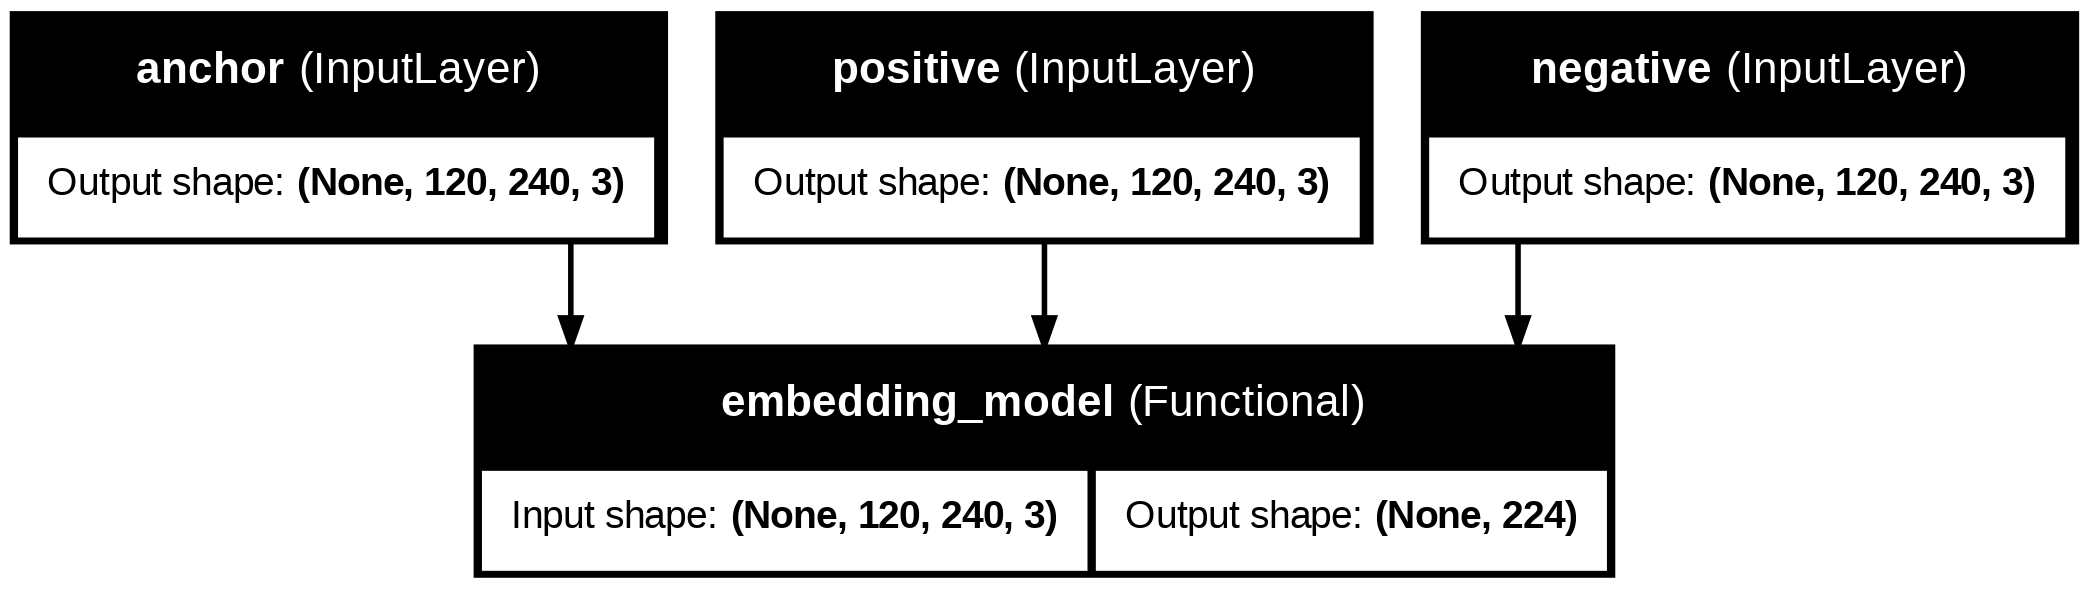

In [ ]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [ ]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 224)       │  2,935,136 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

In [ ]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 448)            │       573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 448)            │         1,792 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 224)            │       100,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 224)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

## Compilation and Training

**TripletLoss** with margin=0.4:
minimizes max(d(a, p) - d(a, n) + margin, 0) where d is cosine distance.

**Monirored metrics**:
- ap_sim - average cosine similarity between anchor and positive (want: high)
- an_sim - average cosine similarity between anchor and negative (want: low)
- margin - difference ap_sim - an_sim (want: positive and increasin)
- triplet_acc - fraction of triplets where ap_sim > an_sim

**Callbacks**:
- EarlyStopping(patience=4) - stops training if vall_loss does not improve
- ReduceLROPlateau(patience=2) - reduces learning rate on plateau
- start_from_epoch=5 - early stopping is inactive during warm-up epochs

In [26]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [ ]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [ ]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - an_sim: 9.3160e-06 - ap_sim: 0.0799 - loss: 0.3332 - margin: 0.0798 - triplet_acc: 0.6375
Epoch 1: val_loss improved from None to 0.23521, saving model to checkpoints/mobile_siamese_triplet/best.weights.h5

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.weights.h5
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 606s 353ms/step - an_sim: -8.4526e-04 - ap_sim: 0.1520 - loss: 0.2886 - margin: 0.1529 - triplet_acc: 0.6910 - val_an_sim: 0.0821 - val_ap_sim: 0.3211 - val_loss: 0.2352 - val_margin: 0.2391 - val_triplet_acc: 0.7557 - learning_rate: 1.0000e-05
Epoch 2/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - an_sim: 0.0015 - ap_sim: 0.3072 - loss: 0.2192 - margin: 0.3057 - triplet_acc: 0.7659
Epoch 2: val_loss improved from 0.23521 to 0.19300, saving model to checkpoints/mobile_siamese_triplet/best.weights.h5

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.weights.h5
1511/1511 ━━━━━━━━━━━━━━━

In [ ]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

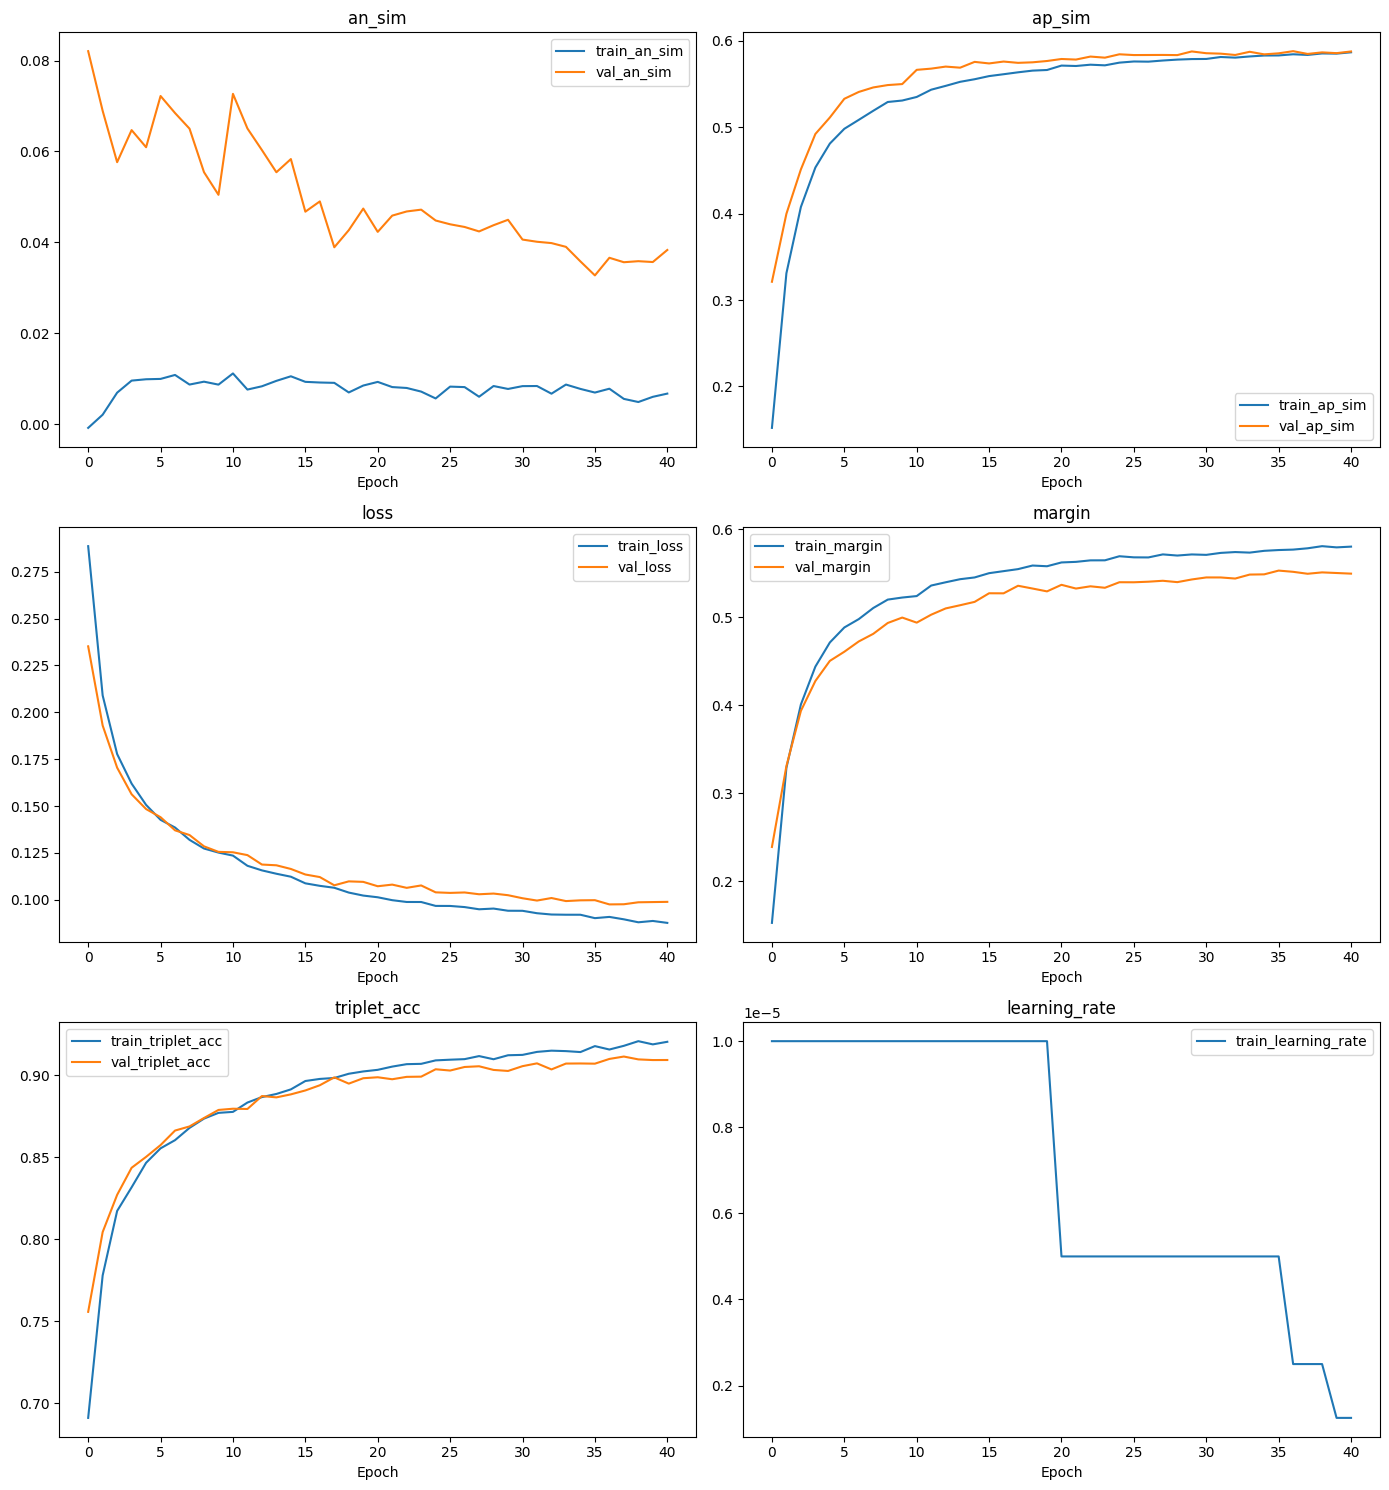

In [ ]:
plot_keras_history(history)

In [ ]:
def save_model(model: BaseMetricTrainer, path: str):
    model.siamese_network.save(f"{path}/mobilenet_siamese_model_204_{config.current_time}.keras")
    model.embedding_model.save(f"{path}/mobilenet_embedding_model_204_{config.current_time}.keras")

In [ ]:
save_model(model=trainer, path="./models")

In [ ]:
save_model(model=trainer, path=f"./{config.project_path}/data/datasets/experiments")

In [27]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_204_20260331-113102.keras")

In [ ]:
metrics_val = trainer.evaluate_dict(val_triplet)
logger.info(f"{metrics_val}")

1007/1007 ━━━━━━━━━━━━━━━━━━━━ 133s 107ms/step - an_sim: 0.0354 - ap_sim: 0.5869 - loss: 0.0984 - margin: 0.5515 - triplet_acc: 0.9103
19:15:10 - mobile_test_204_4 - INFO - {'an_sim': 0.03542326018214226, 'ap_sim': 0.5868982076644897, 'loss': 0.09836617112159729, 'margin': 0.5514754056930542, 'triplet_acc': 0.9102814793586731}


In [ ]:
metrics_test = trainer.evaluate_dict(test_triplet)
logger.info(f"{metrics_test}")

560/560 ━━━━━━━━━━━━━━━━━━━━ 61s 73ms/step - an_sim: 0.0245 - ap_sim: 0.6354 - loss: 0.0789 - margin: 0.6109 - triplet_acc: 0.9306
19:16:11 - mobile_test_204_4 - INFO - {'an_sim': 0.024535009637475014, 'ap_sim': 0.6354480385780334, 'loss': 0.07888692617416382, 'margin': 0.6109129190444946, 'triplet_acc': 0.9305834770202637}


In [28]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [29]:
def display_heatmap(
    df: pd.DataFrame,
    title: str = "Confusion Matrix",
    show_accuracy: bool = True,
) -> None:
    """
    Display confusion matrix heatmap with optional accuracy in title.
    """

    if show_accuracy:
        correct = np.trace(df.values)
        total = df.values.sum()
        acc = correct / total if total > 0 else 0.0

        title = f"{title} (Acc={acc:.3f})"

    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title(title)

    plt.show()

## Triplet Evaluation

`TripletEvaluator` evaluates the model in terms of **pairwise similarity**:

- Generates triplets (anchor, positive, negative) from the test set
- Computes cosine similarity between anchor-positive and anchor-negative pairs
- **AUC** — ability to discriminate similar pairs from dissimilar ones
- **Triplet accuracy** — % of triplets where `sim(a,p) > sim(a,n)`

This evaluation measures the quality of the similarity space,
independently of the author identification strategy.

In [33]:
triplet_evaluator = TripletEvaluator(
    siamese_network=trainer.siamese_network,
    logger=logger,
)

In [34]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

11:03:45 - mobile_test_204_4 - INFO - === Triplet Evaluation Started ===
11:03:47 - mobile_test_204_4 - INFO - === Collecting triplet results ===
11:04:25 - mobile_test_204_4 - INFO - Total triplets collected: 560
11:04:25 - mobile_test_204_4 - INFO - [LOCAL] acc=0.9324 gap=0.6105 error=0.0676 auc=0.9317
11:04:25 - mobile_test_204_4 - INFO - === Computing global metrics ===
11:04:25 - mobile_test_204_4 - INFO - === Global metrics computed ===
11:04:25 - mobile_test_204_4 - INFO - === Triplet Evaluation Finished ===


In [35]:
logger.info(
    f"AUC: {triplet_report.local_metrics.auc:.2f}, "
    f"Accuracy: {triplet_report.local_metrics.triplet_accuracy:.2f}"
)

11:04:25 - mobile_test_204_4 - INFO - AUC: 0.93, Accuracy: 0.93


In [ ]:
y_true = np.concatenate([
    np.ones(len(triplet_report.df_triplets)),
    np.zeros(len(triplet_report.df_triplets))
])
y_pred = np.concatenate([
    triplet_report.df_triplets["sim_ap"].values,
    triplet_report.df_triplets["sim_an"].values
])

### ROC Curve

The `ROC curve` evaluates the ability of the embedding space to distinguish between positive (same writer) and negative (different writer) pairs across all possible similarity thresholds.
The high `AUC` (≈0.94) indicates that the model learns a well-structured embedding space where genuine pairs are consistently assigned higher similarity scores than impostor pairs.

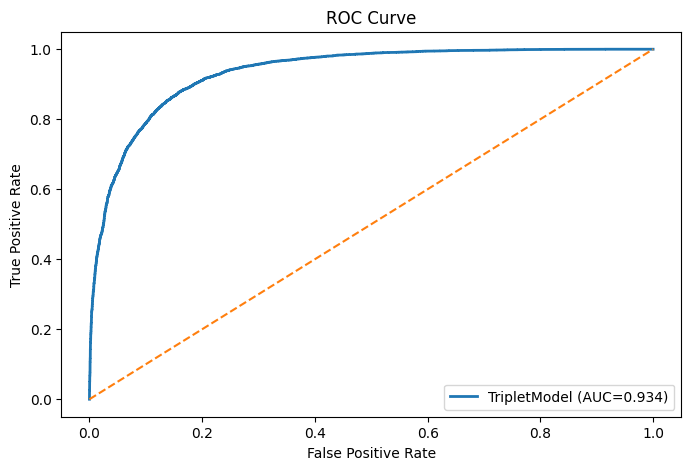

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, lw=2, label=f'TripletModel (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

### Precision-Recall Curve

The `precision-recall` analysis highlights the trade-off between correctly identifying matching pairs (recall) and avoiding false matches (precision).
As expected, lower thresholds increase recall but introduce more false positives, while higher thresholds improve precision at the cost of missing true matches.
This curve is useful for selecting an operating threshold depending on the application requirements.

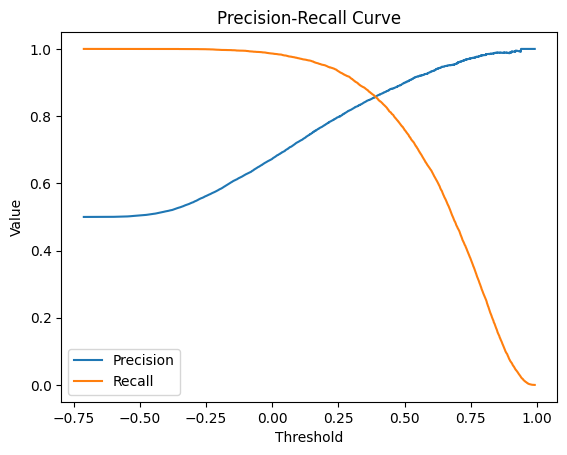

In [ ]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred)

plt.figure()
plt.plot(thresholds_pr, precision[:-1], label='Precision')
plt.plot(thresholds_pr, recall[:-1], label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

### Similarity Distribution

The similarity distribution plot shows the separation between positive pairs (same writer) and negative pairs (different writers) in the embedding space.
Positive pairs tend to have higher similarity values, while negative pairs are mostly concentrated in lower similarity regions.
This indicates that the model successfully learns a meaningful representation where samples from the same writer are closer in the feature space.

However, there is a noticeable overlap between the two distributions, particularly in the mid-range similarity values.
This overlap corresponds to ambiguous cases where the model struggles to distinguish between similar handwriting styles, leading to potential false positives and false negatives.

The degree of overlap explains why the model does not achieve perfect accuracy, despite the high AUC and triplet accuracy scores.
Reducing this overlap is key to further improving the model performance.

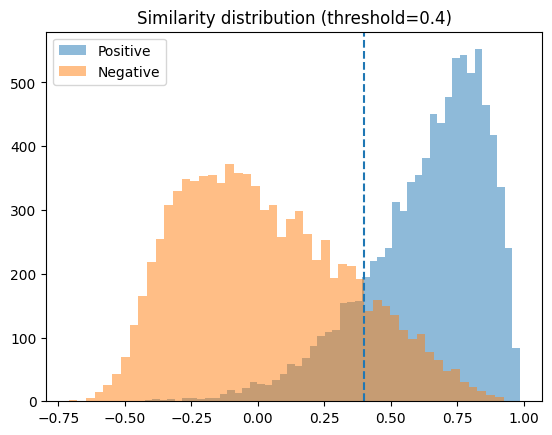

In [36]:
plt.hist(triplet_report.df_triplets["sim_ap"], bins=50, alpha=0.5, label="Positive")
plt.hist(triplet_report.df_triplets["sim_an"], bins=50, alpha=0.5, label="Negative")
plt.axvline(0.4, linestyle='--')
plt.legend()
plt.title("Similarity distribution (threshold=0.4)")
plt.show()

### Confusion Matrix

The `confusion matrix` provides insight into which writers are more frequently confused by the model.
Strong diagonal values indicate correct identification, while off-diagonal entries reveal pairs of writers with similar handwriting characteristics.
This analysis helps identify systematic errors and potential limitations of the learned embedding space.

**Triplet-level Confusion Matrix**

The first confusion matrix is computed from individual triplet predictions.

Each decision is based on a local comparison between a positive and a negative sample.

This matrix reflects how often the model assigns the correct writer label in pairwise similarity decisions.

Due to the local nature of these comparisons, the matrix may contain noise and variability.

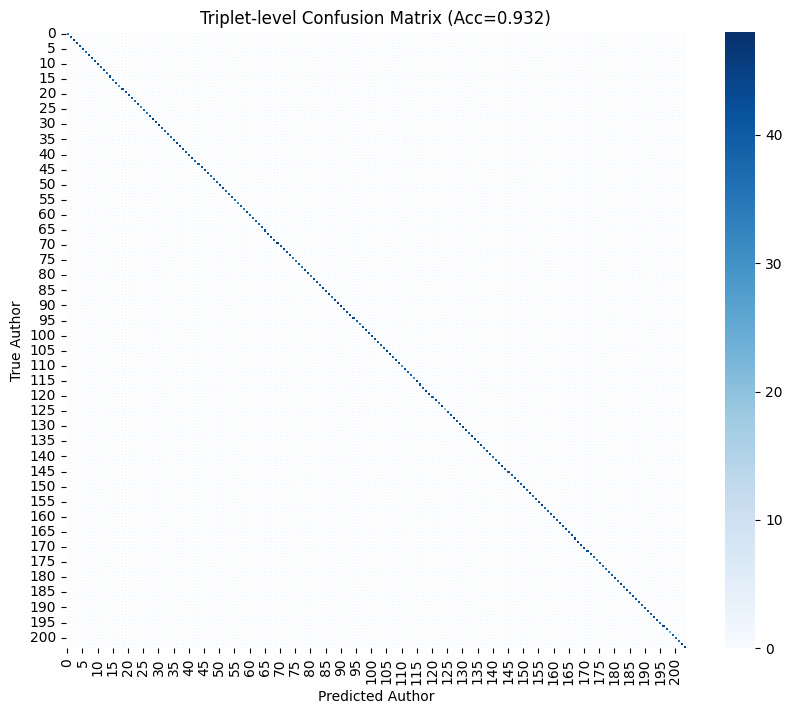

In [37]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Triplet-level Confusion Matrix")

**Author-level Confusion Matrix**

The second confusion matrix is derived from aggregated metrics across triplets.

For each writer, the model selects the most representative prediction based on a scoring function combining accuracy and similarity gap.

This results in a more stable and global evaluation of the model’s ability to distinguish between different writers.

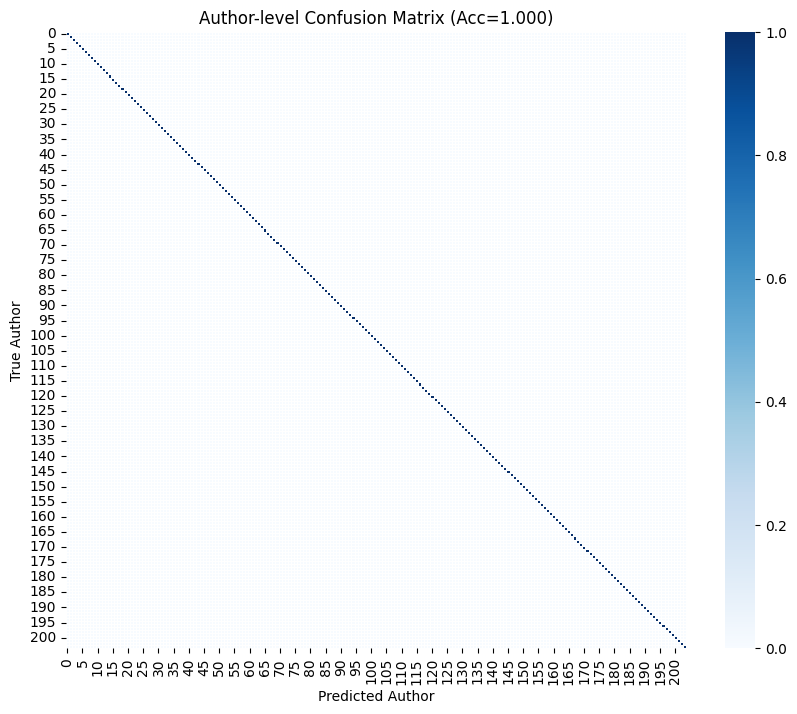

In [38]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix")

**Comparison**

While the triplet-level matrix evaluates local decision quality, the author-level matrix reflects global identification performance.

Together, they provide a comprehensive understanding of both the embedding quality and the consistency of writer discrimination.

In [39]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.884809,36,0.951518,0.951518
1,1,1,1.0,0.717423,42,0.860779,0.860779
2,2,2,1.0,0.857607,47,0.936772,0.936772
3,3,3,1.0,0.625855,44,0.811140,0.811140
4,4,4,1.0,0.583546,42,0.788205,0.788205
...,...,...,...,...,...,...,...
199,199,199,1.0,0.716198,39,0.860115,0.860115
200,200,200,1.0,0.490509,38,0.737770,0.737770
201,201,201,1.0,0.488231,37,0.736535,0.736535
202,202,202,1.0,0.881287,45,0.949609,0.949609


In [30]:
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [31]:
display_generator_info(val_gen)

13:49:52 - mobile_test_204_4 - INFO - Generator: DataGenerator
13:49:52 - mobile_test_204_4 - INFO - Number of samples: 32223
13:49:52 - mobile_test_204_4 - INFO - Batch size: 32
13:49:52 - mobile_test_204_4 - INFO - Steps per epoch: 1007
13:49:52 - mobile_test_204_4 - INFO - Shape: (180, 360)
13:49:52 - mobile_test_204_4 - INFO - Number of authors: 204


In [32]:
display_generator_info(test_gen)

13:49:52 - mobile_test_204_4 - INFO - Generator: DataGenerator
13:49:52 - mobile_test_204_4 - INFO - Number of samples: 8946
13:49:52 - mobile_test_204_4 - INFO - Batch size: 16
13:49:52 - mobile_test_204_4 - INFO - Steps per epoch: 560
13:49:52 - mobile_test_204_4 - INFO - Shape: (180, 360)
13:49:52 - mobile_test_204_4 - INFO - Number of authors: 204


## Embedding Evaluation

The main evaluation of the identification system.

**`EmbeddingExtractor`** uses `trainer.embedding_model` (not the full siamese network)
to extract one embedding per patch from the test set.

**Distance metrics:**
- `intra_distance` — average distance between patches from the **same** author
- `inter_distance` — average distance between patches from **different** authors
- A ratio `inter/intra >> 1` indicates good class separation in the embedding space

**Identification strategies:**
| Strategy | How it predicts the author of a patch |
|---|---|
| `1nn` | author of the nearest patch in the embedding space |
| `mean` | author whose mean embedding is most similar |
| `centroid` | author whose centroid (mean of train embeddings) is closest |
| `topk` | most frequent author among the K nearest neighbors |

**Aggregators — how predictions are aggregated at author level:**
| Aggregator | Logic |
|---|---|
| `patch` | accuracy per individual patch |
| `vote` | majority vote over all patches of the author |
| `score` | prediction by maximum average similarity |

> **The primary metric is `vote accuracy`.**
> Low patch accuracy (~60-80%) is expected and does not indicate model failure —
> an isolated patch can be ambiguous. Author identity emerges by aggregating
> evidence from multiple patches.

In [33]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [34]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [35]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [36]:
val_gen_results = emb_evaluator.evaluate(val_gen)

13:49:52 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
13:49:52 - mobile_test_204_4 - INFO - Extracting embeddings from the model
13:49:54 - mobile_test_204_4 - INFO - Processing 1007 batches to extract embeddings
13:52:39 - mobile_test_204_4 - INFO - Extracted embeddings for 32223 samples
13:52:39 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(32223, 224)
13:52:39 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:52:39 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


13:53:25 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
13:53:25 - mobile_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
13:53:25 - mobile_test_204_4 - INFO - Applying strategy: 1nn
13:53:31 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:53:31 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:53:31 - mobile_test_204_4 - INFO - Applying aggregator: score
13:53:31 - mobile_test_204_4 - INFO - patch acc=0.3438Strategy '1nn' results: , vote acc=0.9902Strategy '1nn' results: , score acc=0.9902
13:53:31 - mobile_test_204_4 - INFO - Applying strategy: mean
13:57:29 - mobile_test_204_4 - INFO - Applying aggregator: patch
13:57:29 - mobile_test_204_4 - INFO - Applying aggregator: vote
13:57:29 - mobile_test_204_4 - INFO - Applying aggregator: score
13:57:29 - mobile_test_204_4 - INFO - patch acc=0.2821Strategy 'mean' results: , vote acc=0.5931Strategy 'mean' results: , score acc=0.5686
13:57:29 - mobile_test_204_4

In [37]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

14:04:07 - mobile_test_204_4 - INFO - Intra distance: 0.3647496998310089
14:04:07 - mobile_test_204_4 - INFO - Inter distance: 0.9593325257301331
14:04:07 - mobile_test_204_4 - INFO - Strategy: 1nn
14:04:07 - mobile_test_204_4 - INFO - Patch accuracy: 0.3438
14:04:07 - mobile_test_204_4 - INFO - Vote accuracy: 0.9902
14:04:07 - mobile_test_204_4 - INFO - Score accuracy: 0.9902
14:04:07 - mobile_test_204_4 - INFO - ----------------------------------------
14:04:07 - mobile_test_204_4 - INFO - Strategy: mean
14:04:07 - mobile_test_204_4 - INFO - Patch accuracy: 0.2821
14:04:07 - mobile_test_204_4 - INFO - Vote accuracy: 0.5931
14:04:07 - mobile_test_204_4 - INFO - Score accuracy: 0.5686
14:04:07 - mobile_test_204_4 - INFO - ----------------------------------------
14:04:07 - mobile_test_204_4 - INFO - Strategy: centroid
14:04:07 - mobile_test_204_4 - INFO - Patch accuracy: 0.3301
14:04:07 - mobile_test_204_4 - INFO - Vote accuracy: 0.9559
14:04:07 - mobile_test_204_4 - INFO - Score accur

In [38]:
test_gen_results = emb_evaluator.evaluate(
    data_generator=test_gen,
    reducer=UMAPReducer(n_components=3)
)

14:04:07 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
14:04:07 - mobile_test_204_4 - INFO - Extracting embeddings from the model
14:04:07 - mobile_test_204_4 - INFO - Processing 560 batches to extract embeddings
14:05:35 - mobile_test_204_4 - INFO - Extracted embeddings for 8946 samples
14:05:35 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(8946, 224)
14:05:35 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
14:05:35 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


14:05:51 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
14:05:51 - mobile_test_204_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
14:05:51 - mobile_test_204_4 - INFO - Applying strategy: 1nn
14:05:52 - mobile_test_204_4 - INFO - Applying aggregator: patch
14:05:52 - mobile_test_204_4 - INFO - Applying aggregator: vote
14:05:52 - mobile_test_204_4 - INFO - Applying aggregator: score
14:05:52 - mobile_test_204_4 - INFO - patch acc=0.6667Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
14:05:52 - mobile_test_204_4 - INFO - Applying strategy: mean
14:06:22 - mobile_test_204_4 - INFO - Applying aggregator: patch
14:06:22 - mobile_test_204_4 - INFO - Applying aggregator: vote
14:06:22 - mobile_test_204_4 - INFO - Applying aggregator: score
14:06:22 - mobile_test_204_4 - INFO - patch acc=0.3665Strategy 'mean' results: , vote acc=0.5882Strategy 'mean' results: , score acc=0.5588
14:06:22 - mobile_test_204_4

In [39]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

14:07:16 - mobile_test_204_4 - INFO - Intra distance: 0.35477781295776367
14:07:16 - mobile_test_204_4 - INFO - Inter distance: 0.9752946496009827
14:07:16 - mobile_test_204_4 - INFO - Strategy: 1nn
14:07:16 - mobile_test_204_4 - INFO - Patch accuracy: 0.6667
14:07:16 - mobile_test_204_4 - INFO - Vote accuracy: 1.0000
14:07:16 - mobile_test_204_4 - INFO - Score accuracy: 1.0000
14:07:16 - mobile_test_204_4 - INFO - ----------------------------------------
14:07:16 - mobile_test_204_4 - INFO - Strategy: mean
14:07:16 - mobile_test_204_4 - INFO - Patch accuracy: 0.3665
14:07:16 - mobile_test_204_4 - INFO - Vote accuracy: 0.5882
14:07:16 - mobile_test_204_4 - INFO - Score accuracy: 0.5588
14:07:16 - mobile_test_204_4 - INFO - ----------------------------------------
14:07:16 - mobile_test_204_4 - INFO - Strategy: centroid
14:07:16 - mobile_test_204_4 - INFO - Patch accuracy: 0.4392
14:07:16 - mobile_test_204_4 - INFO - Vote accuracy: 0.9167
14:07:16 - mobile_test_204_4 - INFO - Score accu

## Visualization and Error Analysis

`EmbeddingVisualizer` allows exploring the embedding space and model errors.

- `plot_embeddings()` — UMAP projection of the embedding space, colored by author
- `plot_centroids()` — centroid of each author in UMAP space
- `log_error_samples()` — patches misclassified at patch level
- `plot_confusion()` — confusion matrix by `aggregators`

> Patch-level errors are informative: they reveal which authors have similar styles or nearby embeddings in the learned space.

> If vote accuracy is high despite patch errors, the model is working correctly — individual patch ambiguity is resolved by majority aggregation.

In [40]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    split=test,
)

In [41]:
viz.set_strategy("1nn")

In [42]:
viz.plot_embeddings()

In [43]:
viz.log_samples(n=20)

14:08:11 - mobile_test_204_4 - INFO - Showing 20 samples:
14:08:11 - mobile_test_204_4 - INFO - [idx=4334] lines2_Page_34 → lines2_Page_34
14:08:11 - mobile_test_204_4 - INFO - [idx=4309] lines2_Page_33 → lines3_Page_52
14:08:11 - mobile_test_204_4 - INFO - [idx=7781] lines3_Page_46 → lines3_Page_46
14:08:11 - mobile_test_204_4 - INFO - [idx=2713] lines1_Page_65 → lines1_Page_65
14:08:11 - mobile_test_204_4 - INFO - [idx=2334] lines1_Page_56 → lines1_Page_56
14:08:11 - mobile_test_204_4 - INFO - [idx=5447] lines2_Page_60 → lines1_Page_46
14:08:11 - mobile_test_204_4 - INFO - [idx=8416] lines3_Page_60 → lines1_Page_15
14:08:11 - mobile_test_204_4 - INFO - [idx=7487] lines3_Page_37 → lines3_Page_37
14:08:11 - mobile_test_204_4 - INFO - [idx=6485] lines3_Page_15 → lines3_Page_15
14:08:11 - mobile_test_204_4 - INFO - [idx=1861] lines1_Page_45 → lines1_Page_45
14:08:11 - mobile_test_204_4 - INFO - [idx=469] lines1_Page_11 → lines1_Page_11
14:08:11 - mobile_test_204_4 - INFO - [idx=2470] lin

In [44]:
viz.plot_centroids()

14:08:13 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.7803 | clusters=18


**Patch-level Confusion Matrix**

The patch-level confusion matrix evaluates the model’s predictions on individual image patches.

Since each patch contains only partial handwriting information, predictions at this level are inherently noisy.

This results in noticeable confusion between authors with similar local stroke patterns.

14:10:00 - mobile_test_204_4 - INFO - 1nn - by patch accuracy 0.6667


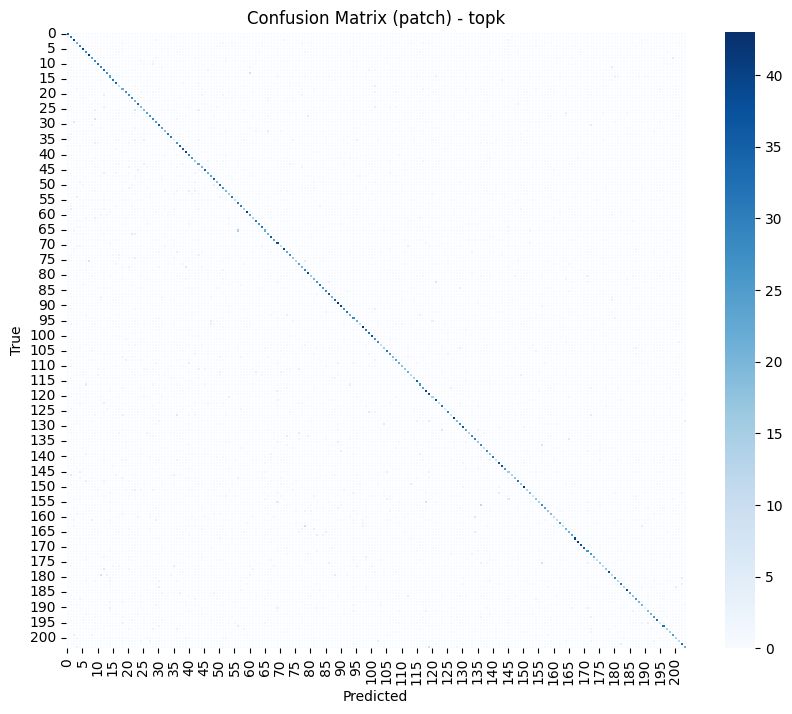

In [55]:
one_nn_patch_acc = test_gen_results.strategy_results['1nn']['patch'].metrics
logger.info(f"1nn - by patch accuracy {one_nn_patch_acc['accuracy']:.4f}")
viz.plot_confusion(level="patch")

**Vote-level Confusion Matrix**

The vote-level confusion matrix represents the final classification performance after aggregating predictions across multiple patches.

By combining information from several patches, the model achieves more robust and stable predictions, significantly reducing classification errors.

14:08:29 - mobile_test_204_4 - INFO - 1nn - by vote accuracy 1.0


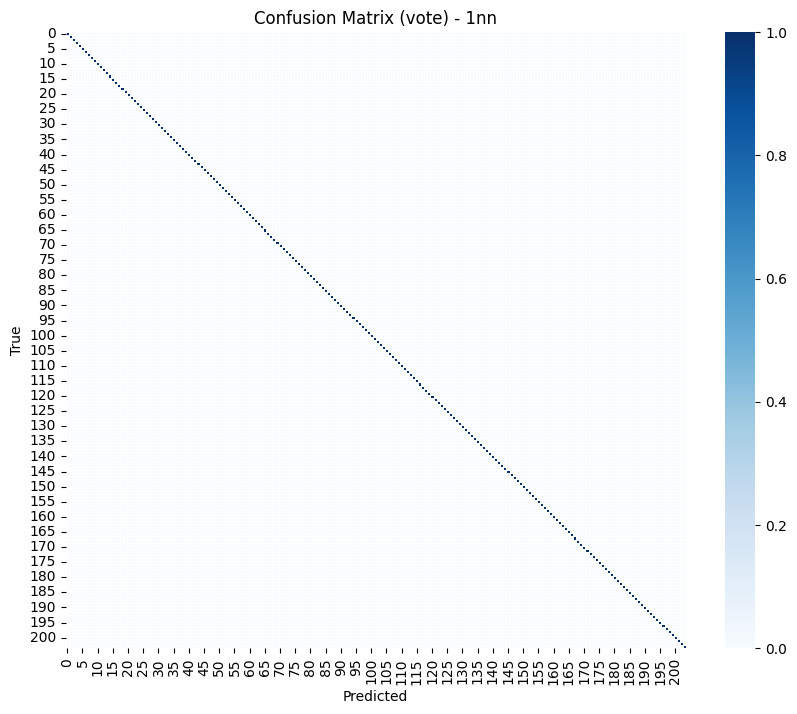

In [46]:
one_nn_vote_acc = test_gen_results.strategy_results['1nn']['vote'].metrics
logger.info(f"1nn - by vote accuracy {one_nn_vote_acc['accuracy']}")
viz.plot_confusion(level="vote")

**Comparison**

The comparison between patch-level and vote-level confusion matrices highlights the importance of aggregation.

While individual patch predictions may be ambiguous, the aggregation process effectively resolves these ambiguities, leading to improved author identification performance.

In [47]:
viz.set_strategy("topk")

In [48]:
viz.plot_embeddings()

In [49]:
viz.log_samples(n=20)

14:08:44 - mobile_test_204_4 - INFO - Showing 20 samples:
14:08:44 - mobile_test_204_4 - INFO - [idx=283] lines1_Page_07 → lines3_Page_06
14:08:44 - mobile_test_204_4 - INFO - [idx=8672] lines4_Page_01 → lines3_Page_32
14:08:44 - mobile_test_204_4 - INFO - [idx=581] lines1_Page_14 → lines1_Page_14
14:08:44 - mobile_test_204_4 - INFO - [idx=6063] lines3_Page_05 → lines3_Page_14
14:08:44 - mobile_test_204_4 - INFO - [idx=7854] lines3_Page_48 → lines3_Page_48
14:08:44 - mobile_test_204_4 - INFO - [idx=2661] lines1_Page_64 → lines1_Page_64
14:08:44 - mobile_test_204_4 - INFO - [idx=8113] lines3_Page_53 → lines2_Page_18
14:08:44 - mobile_test_204_4 - INFO - [idx=7394] lines3_Page_35 → lines3_Page_35
14:08:44 - mobile_test_204_4 - INFO - [idx=3386] lines2_Page_12 → lines1_Page_42
14:08:44 - mobile_test_204_4 - INFO - [idx=8358] lines3_Page_59 → lines1_Page_15
14:08:44 - mobile_test_204_4 - INFO - [idx=143] lines1_Page_04 → lines4_Page_07
14:08:44 - mobile_test_204_4 - INFO - [idx=3530] lines

In [50]:
viz.plot_centroids()

14:08:46 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.7803 | clusters=18


14:09:24 - mobile_test_204_4 - INFO - topk - by vote accuracy 0.9951


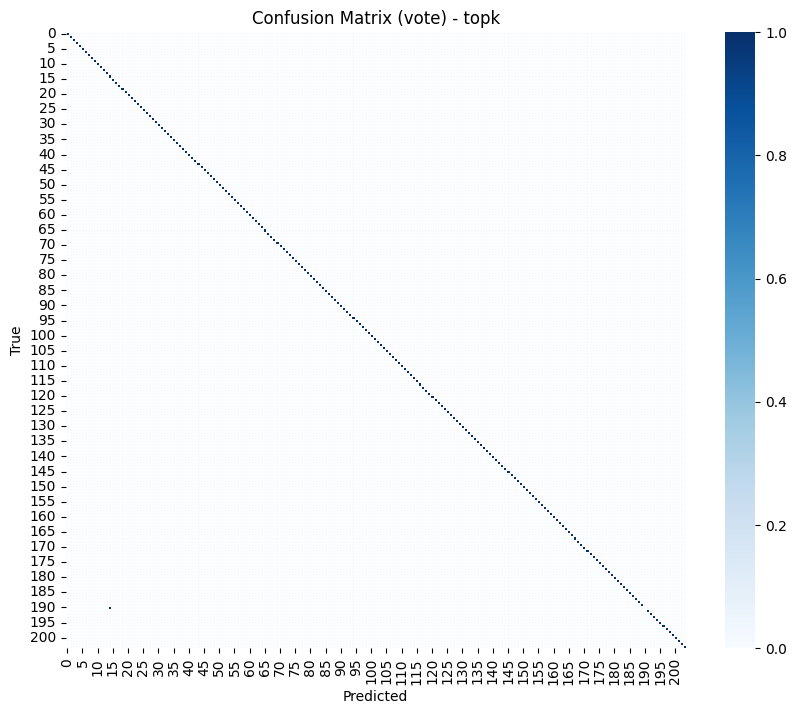

In [52]:
topk_vote_acc = test_gen_results.strategy_results['topk']['vote'].metrics
logger.info(f"topk - by vote accuracy {topk_vote_acc['accuracy']:.4f}")
viz.plot_confusion("vote")

In [53]:
res_topk_data = test_gen_results.strategy_results['topk']['vote'].data
topk_error_data = res_topk_data[res_topk_data['correct'] == False]
topk_error_data

,author,author_pred,correct
190,190,14,False


In [54]:
viz.plot_centroids([190, 14])

14:09:33 - mobile_test_204_4 - INFO - Estimated DBSCAN eps=0.7803 | clusters=18
